/tmp/ipykernel_1343/894747695.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/tmp/ipykernel_1343/894747695.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices.fillna(method='ffill', inplace=True)


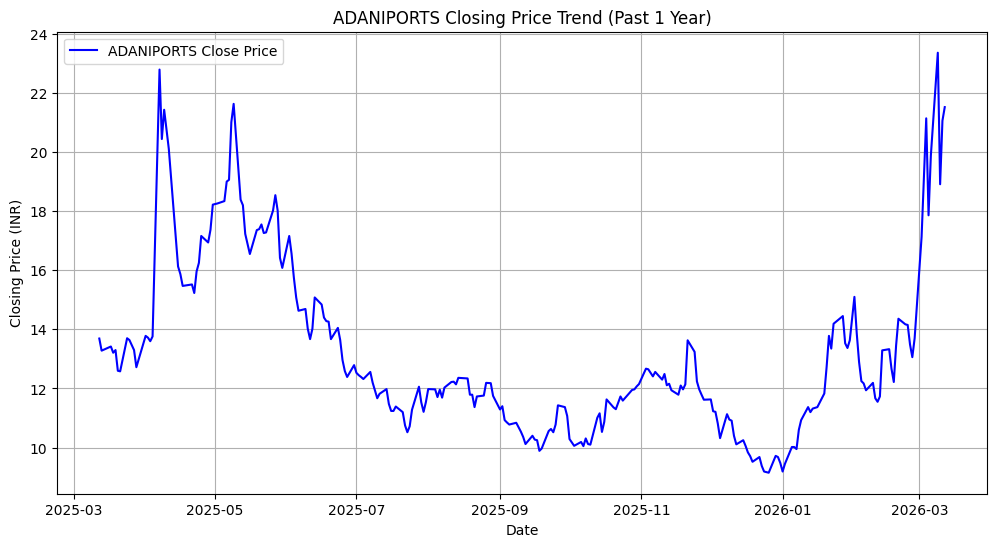

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('ADANIPORTS_data.csv')

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Convert the date column to proper format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Extract closing prices and fill missing values
close_prices = df['Close']
close_prices.fillna(method='ffill', inplace=True)

# Visualize the closing price trend
plt.figure(figsize=(12, 6))
plt.plot(close_prices, label='ADANIPORTS Close Price', color='blue')
plt.title('ADANIPORTS Closing Price Trend (Past 1 Year)')
plt.xlabel('Date')
plt.ylabel('Closing Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -1.2793
p-value: 0.6386
Result: Data is NOT stationary. Differencing is required (d=1).


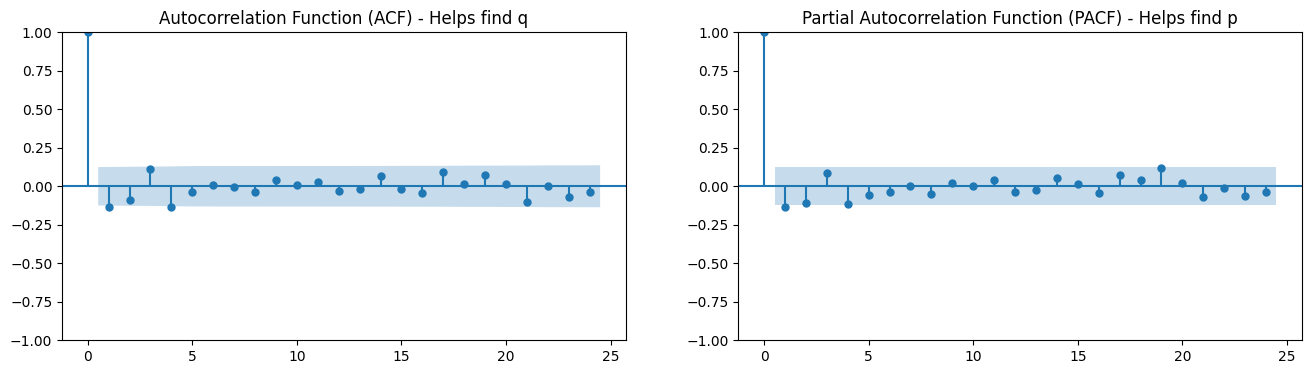

In [3]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# (a) Conduct an ADF test to check for stationarity
print("--- Augmented Dickey-Fuller (ADF) Test ---")
adf_result = adfuller(close_prices)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

if adf_result[1] <= 0.05:
    print("Result: Data is stationary. No differencing needed (d=0).")
    stationary_data = close_prices
    d_val = 0
else:
    print("Result: Data is NOT stationary. Differencing is required (d=1).")
    stationary_data = close_prices.diff().dropna()
    d_val = 1

# (b) Use ACF and PACF plots to determine optimal ARIMA parameters
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(stationary_data, ax=axes[0], title='Autocorrelation Function (ACF) - Helps find q')
plot_pacf(stationary_data, ax=axes[1], title='Partial Autocorrelation Function (PACF) - Helps find p')
plt.show()

--- Fitting ARIMA(1,1,1) Model ---


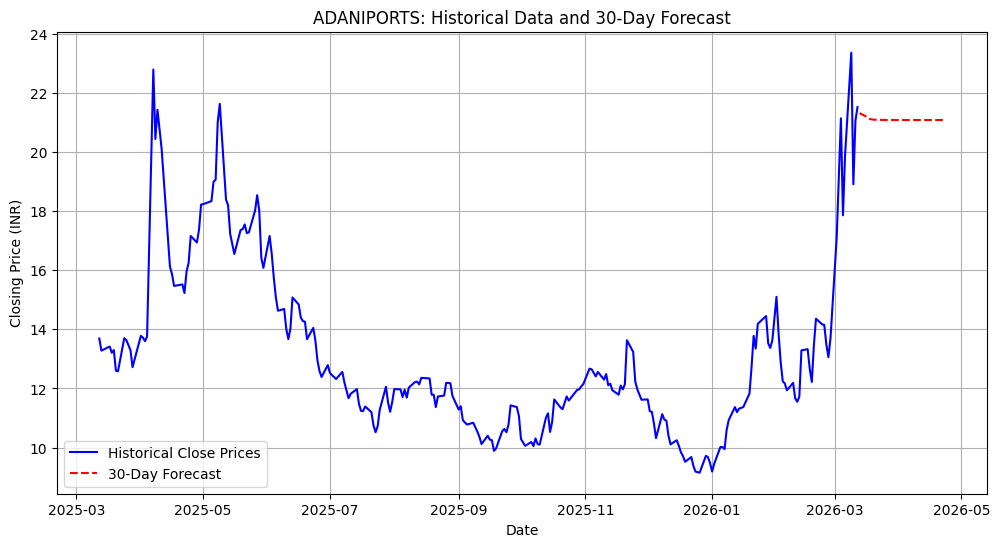


Observation: The ARIMA model predicts a DOWNWARD or STABLE trend for the next 30 days.


In [4]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# 1. Fit the ARIMA model
p = 1
d = d_val
q = 1

print(f"--- Fitting ARIMA({p},{d},{q}) Model ---")
model = ARIMA(close_prices, order=(p, d, q))
fitted_model = model.fit()

# 2. Forecast the next 30 days
forecast_steps = 30
forecast = fitted_model.forecast(steps=forecast_steps)

# Create future dates for the x-axis (excluding weekends)
last_date = close_prices.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast.index = future_dates

# 3. Visualize the forecasted prices alongside historical data
plt.figure(figsize=(12, 6))
plt.plot(close_prices, label='Historical Close Prices', color='blue')
plt.plot(forecast, label='30-Day Forecast', color='red', linestyle='dashed')
plt.title('ADANIPORTS: Historical Data and 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Closing Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# Print out a summary for interpretation
if forecast.iloc[-1] > forecast.iloc[0]:
    print("\nObservation: The ARIMA model predicts an UPWARD trend for the next 30 days.")
else:
    print("\nObservation: The ARIMA model predicts a DOWNWARD or STABLE trend for the next 30 days.")